<a href="https://colab.research.google.com/github/MNTech955/100-days-of-machine-learning/blob/main/random_sample_imputation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('sample_data/train.csv',usecols=['Age','Fare','Survived'])

df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [14]:
df.isnull().mean() * 100

,0
Survived,0.00000
Age,19.86532
Fare,0.00000


In [3]:
X = df.drop(columns=['Survived'])
y = df['Survived']

In [13]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)
X_train

,Age,Fare
30,40.0,27.7208
10,4.0,16.7000
873,47.0,9.0000
182,9.0,31.3875
876,20.0,9.8458
...,...,...
534,30.0,8.6625
584,NaN,8.7125
493,71.0,49.5042
527,NaN,221.7792


In [16]:
#new column imputed
X_train['Age_imputed'] = X_train['Age']
X_test['Age_imputed'] = X_test['Age']

In [17]:
X_test.tail()

,Age,Fare,Age_imputed
89,24.0,8.0500,24.0
80,22.0,9.0000,22.0
846,NaN,69.5500,NaN
870,26.0,7.8958,26.0
251,29.0,10.4625,29.0


In [18]:
#Fill missing Age values using random existing Age values from the dataset
#Instead of using mean or median, this method picks random real ages.
#X_train['Age_imputed'].isnull()-->This checks which rows contain missing values
#X_train['Age_imputed'][X_train['Age_imputed'].isnull()]-->This selects
# ONLY the missing rows.
#X_train['Age'].dropna()->This removes missing values from Age
#X_train['Age'].isnull().sum()->Counts how many missing values exist.
#.sample(X_train['Age'].isnull().sum())->This randomly picks values
# from the non-missing ages.
#.values->Converts sampled values into NumPy array.

X_train['Age_imputed'][X_train['Age_imputed'].isnull()] = X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values
X_test['Age_imputed'][X_test['Age_imputed'].isnull()] = X_train['Age'].dropna().sample(X_test['Age'].isnull().sum()).values

/tmp/ipykernel_10515/3503486967.py:5: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  X_train['Age_imputed'][X_train['Age_imputed'].isnull()] = X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values
/tmp/ipykernel_10515/350348696

In [19]:
X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values

array([ 9.  , 24.  , 31.  , 34.  , 21.  , 27.  , 26.  , 29.  , 31.  ,
       28.  , 32.  , 27.  , 43.  , 35.  , 46.  , 35.  , 26.  , 23.5 ,
       16.  , 49.  , 19.  , 40.5 , 33.  , 18.  , 46.  , 24.  , 22.  ,
       48.  , 33.  , 60.  ,  4.  ,  6.  , 15.  ,  9.  ,  4.  , 51.  ,
       40.  , 36.  , 22.  , 40.  , 42.  , 15.  ,  9.  , 60.  , 39.  ,
       45.  , 60.  ,  4.  , 24.  , 58.  , 31.  , 20.  , 45.  , 30.  ,
       51.  , 35.  , 61.  , 58.  , 33.  , 35.  , 11.  , 19.  , 13.  ,
        5.  , 49.  , 70.  , 22.  , 31.  , 38.  , 34.5 , 25.  , 30.  ,
       18.  , 14.  ,  7.  , 28.  , 32.  , 44.  ,  3.  , 45.  ,  4.  ,
       31.  , 54.  ,  0.42, 33.  , 47.  ,  0.75, 42.  , 23.  , 26.  ,
       59.  , 40.  , 22.  , 46.  ,  5.  , 40.  , 34.  , 30.  , 27.  ,
       60.  , 50.  , 20.  , 21.  , 52.  ,  0.83, 31.  , 35.  , 33.  ,
       17.  , 18.  , 22.  , 47.  , 25.  , 22.  , 48.  ,  0.83, 52.  ,
       11.  , 54.  , 43.  , 25.  , 45.  ,  4.  , 24.  , 16.  , 31.  ,
       20.  , 15.  ,

In [20]:
X_train['Age'].isnull().sum()

np.int64(148)

In [22]:
X_train

,Age,Fare,Age_imputed
30,40.0,27.7208,40.0
10,4.0,16.7000,4.0
873,47.0,9.0000,47.0
182,9.0,31.3875,9.0
876,20.0,9.8458,20.0
...,...,...,...
534,30.0,8.6625,30.0
584,NaN,8.7125,24.0
493,71.0,49.5042,71.0
527,NaN,221.7792,21.0


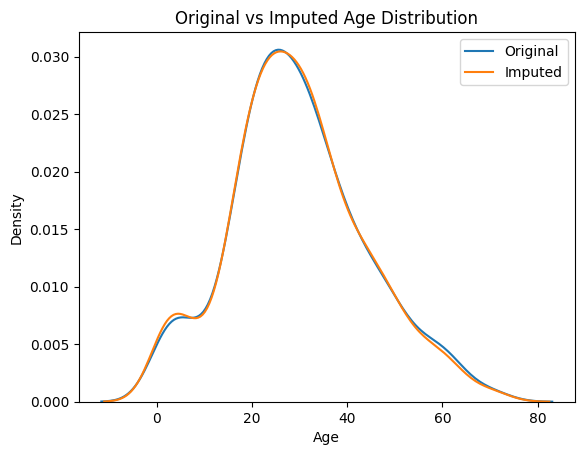

In [24]:
# KDE plot for original and imputed Age columns
sns.kdeplot(X_train['Age'], label='Original')
sns.kdeplot(X_train['Age_imputed'], label='Imputed')

# Show legend
plt.legend()

# Add title
plt.title('Original vs Imputed Age Distribution')

# Show plot
plt.show()

In [25]:
print('Original variable variance: ', X_train['Age'].var())
print('Variance after random imputation: ', X_train['Age_imputed'].var())

Original variable variance:  204.3495133904614
Variance after random imputation:  202.17290996065043


In [26]:
X_train[['Fare', 'Age', 'Age_imputed']].cov()

,Fare,Age,Age_imputed
Fare,2368.246832,71.512440,54.228975
Age,71.512440,204.349513,204.349513
Age_imputed,54.228975,204.349513,202.172910


<Axes: >

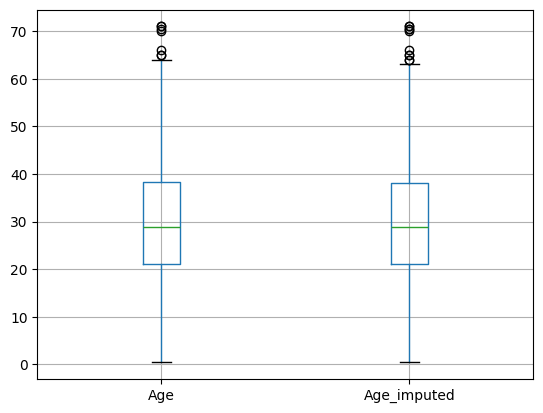

In [27]:
X_train[['Age', 'Age_imputed']].boxplot()

In [ ]:
#Meaning:

# passengers with same Fare
# get same random Age selection
#.sample(1, random_state=52)->Without random_state:->results change every run
sampled_value = X_train['Age'].dropna().sample(1, random_state=int(observation['Fare']))


In [28]:
data = pd.read_csv('sample_data/house-train.csv',usecols=['GarageQual','FireplaceQu', 'SalePrice'])

In [29]:
data.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [30]:
data.isnull().mean() * 100

,0
FireplaceQu,47.260274
GarageQual,5.547945
SalePrice,0.000000


In [31]:
X = data
y = data['SalePrice']

In [32]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [33]:
X_train['GarageQual_imputed'] = X_train['GarageQual']
X_test['GarageQual_imputed'] = X_test['GarageQual']

X_train['FireplaceQu_imputed'] = X_train['FireplaceQu']
X_test['FireplaceQu_imputed'] = X_test['FireplaceQu']

In [34]:
X_train.sample(5)

,FireplaceQu,GarageQual,SalePrice,GarageQual_imputed,FireplaceQu_imputed
1092,Gd,TA,136500,TA,Gd
312,Gd,TA,119900,TA,Gd
681,NaN,TA,159434,TA,NaN
618,Gd,TA,314813,TA,Gd
378,Ex,TA,394432,TA,Ex


In [35]:
X_train['GarageQual_imputed'][X_train['GarageQual_imputed'].isnull()] = X_train['GarageQual'].dropna().sample(X_train['GarageQual'].isnull().sum()).values
X_test['GarageQual_imputed'][X_test['GarageQual_imputed'].isnull()] = X_train['GarageQual'].dropna().sample(X_test['GarageQual'].isnull().sum()).values

X_train['FireplaceQu_imputed'][X_train['FireplaceQu_imputed'].isnull()] = X_train['FireplaceQu'].dropna().sample(X_train['FireplaceQu'].isnull().sum()).values
X_test['FireplaceQu_imputed'][X_test['FireplaceQu_imputed'].isnull()] = X_train['FireplaceQu'].dropna().sample(X_test['FireplaceQu'].isnull().sum()).values

/tmp/ipykernel_10515/856878696.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  X_train['GarageQual_imputed'][X_train['GarageQual_imputed'].isnull()] = X_train['GarageQual'].dropna().sample(X_train['GarageQual'].isnull().sum()).values
/tm

In [36]:
temp = pd.concat(
        [
            X_train['GarageQual'].value_counts() / len(X_train['GarageQual'].dropna()),
            X_train['GarageQual_imputed'].value_counts() / len(X_train)
        ],
        axis=1)

temp.columns = ['original', 'imputed']

In [37]:
temp

,original,imputed
TA,0.951043,0.953767
Fa,0.037171,0.035103
Gd,0.009973,0.009418
Po,0.000907,0.000856
Ex,0.000907,0.000856


In [38]:
temp = pd.concat(
        [
            X_train['FireplaceQu'].value_counts() / len(X_train['FireplaceQu'].dropna()),
            X_train['FireplaceQu_imputed'].value_counts() / len(df)
        ],
        axis=1)

temp.columns = ['original', 'imputed']

temp

,original,imputed
Gd,0.494272,0.649832
TA,0.412439,0.542088
Fa,0.040917,0.053872
Po,0.027823,0.034792
Ex,0.024550,0.030303


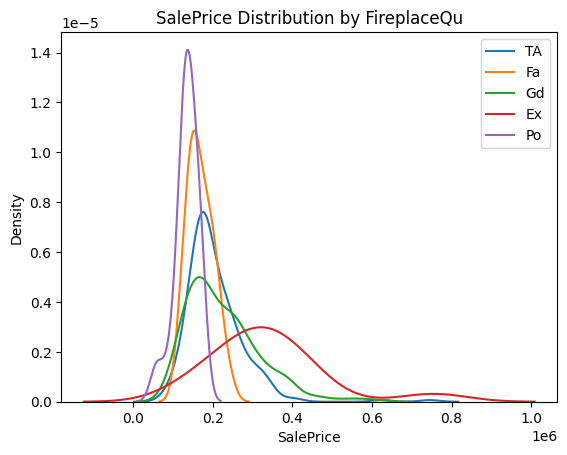

In [43]:
#X_train['FireplaceQu']->Selects the FireplaceQu column.
#.dropna()->Removes missing values (NaN).
#.unique()->Gets unique category names only.
#for category in ...->Loop runs one time for each category.
#X_train[X_train['FireplaceQu'] == category]->This filters only rows belonging to the current category.
#Example:->category = 'TA'->Then this becomes:->X_train[X_train['FireplaceQu'] == 'TA']->Meaning:->Give only rows where FireplaceQu is TA.
#X_train[X_train['FireplaceQu'] == category]['SalePrice']->Get SalePrice values for houses whose FireplaceQu equals the current category.
for category in X_train['FireplaceQu'].dropna().unique():
    sns.kdeplot(
        X_train[X_train['FireplaceQu'] == category]['SalePrice'],
        label=category
    )

plt.title('SalePrice Distribution by FireplaceQu')
plt.legend()
plt.show()

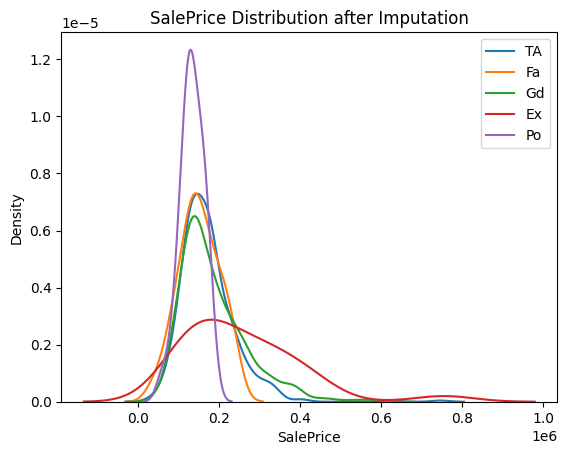

In [42]:

for category in X_train['FireplaceQu_imputed'].dropna().unique():
    sns.kdeplot(
        X_train[X_train['FireplaceQu_imputed'] == category]['SalePrice'],
        label=category
    )

plt.legend()
plt.title('SalePrice Distribution after Imputation')
plt.xlabel('SalePrice')
plt.ylabel('Density')

plt.show()